In [1]:
# Imports
from scipy.io import loadmat
import pandas as pd
import numpy as np
import plotly.express as px
import torch.nn as nn
import torch
import itertools
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import TensorDataset, DataLoader

In [2]:
data = loadmat('Xtrain.mat')

In [3]:
def data_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    normalized = df/255
    return normalized
    
def slices(s: pd.Series, slice_length) -> tuple[pd.Series, pd.Series]:
    slices = [window for window in s.rolling(window=slice_length+1)]
    res = [(slc.iloc[:-1], slc.iloc[-1]) for slc in slices[slice_length:]]
    return res


In [4]:
def recursive_predict(model, start_window, steps=200):
    model.eval() # set model to evaluation mode
    
    window = start_window.clone().detach() # make sure not to change orginal input
    preds = [] # predictions

    for _ in range(steps):
        with torch.no_grad():
            # LSTM expects input shape (batch_size, seq_len, features)
            pred = model(window.unsqueeze(0)) # Adds dimension to (seq_len, 1) to get correct shape: (1, seq_len, 1)
        
        preds.append(pred.item())

        # shift window
        window = torch.cat([window[1:], pred], dim=0) # removes oldest value and adds new prediction at the end

    return preds

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True # needed because we have (batch_size, seq_len, 1). So batch size is given first
        )
        
        self.fc = nn.Linear(hidden_size, 1) # Connects final layer to output

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)

        # pass through model
        out, _ = self.lstm(x)

        # out contains hidden states for all timesteps:
        # shape: (batch_size, seq_len, hidden_size)
        
        # we only care about last timestep.
        out = out[:, -1, :] #takes last timestep
        out = self.fc(out) # gets prediction
        
        return out

In [21]:
results = []

# how many times to repeat each config
n_runs = 5

# hyperparameters to try
window_sizes = [16, 32]
hidden_sizes = [32, 64]
num_layers_list = [2]
epochs_list = [250, 500, 750]
learning_rates = [1e-3, 5e-4]

# create data
series_full = pd.Series(data['Xtrain'].flatten())
series_full = data_cleaning(series_full).values


# try all combinations of hyperparameters
for window_size, hidden_size, num_layers, epochs, learning_rate in itertools.product(window_sizes, hidden_sizes, num_layers_list, epochs_list, learning_rates):

    print(f"\nRunning: window={window_size}, hidden={hidden_size}, layers={num_layers}, epochs={epochs}, learning rate={learning_rate}")

    # store results across runs
    mae_1_list, mae_200_list = [], []
    mse_1_list, mse_200_list = [], []

    for run in range(n_runs): # repeat training multiple times to average evaluation
        print(f"  Run {run+1}/{n_runs}")

        # recreate dataset with current chosen window
        df = pd.Series(data['Xtrain'].flatten())
        df = data_cleaning(df)

        X, Y = zip(*slices(df, window_size))

        X = np.array(X).reshape(-1, window_size, 1)
        Y = np.array(Y).reshape(-1, 1)

        split = int(0.8 * len(X))

        X_train, X_val = X[:split], X[split:]
        Y_train, Y_val = Y[:split], Y[split:]

        # Convert to PyTorch tensors
        X_train = torch.tensor(X_train, dtype=torch.float32)
        Y_train = torch.tensor(Y_train, dtype=torch.float32)
        X_val = torch.tensor(X_val, dtype=torch.float32)
        Y_val = torch.tensor(Y_val, dtype=torch.float32)

        # create model
        model = LSTMModel(hidden_size=hidden_size, num_layers=num_layers)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5, # halve learning rate when plateauing
            patience=10, # wait 10 epochs
            min_lr=1e-5
        )

        #Shuffle training data
        dataset = TensorDataset(X_train, Y_train)
        loader = DataLoader(
            dataset,
            batch_size=64,
            shuffle=True
        )

        #-------------------------------------------------
        # training
        #-------------------------------------------------
        for epoch in range(epochs):
            model.train()

            train_loss_epoch = 0.0

            for X_batch, Y_batch in loader:
                optimizer.zero_grad()
                noise = torch.randn_like(X_batch) * 0.01 # add noise, model learns to predict with imperfect inputs
                pred = model(X_batch + noise)
                loss = criterion(pred, Y_batch)
                loss.backward() # backpropagation
                optimizer.step() # update parameters

                train_loss_epoch += loss.item()

            train_loss_epoch /= len(loader)
            #print(train_loss_epoch)

            # evaluation for schedular / for automatic learning rate decay at plateau
            model.eval()
            with torch.no_grad():
                val_pred = model(X_val)
                val_loss = criterion(val_pred, Y_val).item()
            
            scheduler.step(val_loss)
        #-------------------------------------------------


        #-------------------------------------------------
        # 1-step evaluation
        #-------------------------------------------------
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val).numpy()
            y_true = Y_val.numpy()

        mae_1 = mean_absolute_error(y_true, val_pred)
        mse_1 = mean_squared_error(y_true, val_pred)
        #-------------------------------------------------


        #-------------------------------------------------
        # 200-step evaluation
        #-------------------------------------------------
        start_idx = split
        start_window = series_full[start_idx:start_idx+window_size]

        # determine max possible steps
        max_steps = len(series_full) - (start_idx + window_size)
        steps = min(200, max_steps)

        true_future = series_full[start_idx+window_size:start_idx+window_size+steps] # true values

        # convert start window to tensor
        start_tensor = torch.tensor(start_window.reshape(window_size, 1), dtype=torch.float32)

        preds = recursive_predict(model, start_tensor, steps) # predictions

        mae_200 = mean_absolute_error(true_future, preds)
        mse_200 = mean_squared_error(true_future, preds)
        #-------------------------------------------------

        # store per run results
        mae_1_list.append(mae_1)
        mae_200_list.append(mae_200)
        mse_1_list.append(mse_1)
        mse_200_list.append(mse_200)


    #-------------------------------------------------
    # store results
    #-------------------------------------------------
    results.append({
        "window": window_size,
        "hidden": hidden_size,
        "layers": num_layers,
        "epochs": epochs,
        "learning_rate" : learning_rate,

        "mae_1_mean": np.mean(mae_1_list),
        "mae_1_std": np.std(mae_1_list),

        "mae_200_mean": np.mean(mae_200_list),
        "mae_200_std": np.std(mae_200_list),

        "mse_1_mean": np.mean(mse_1_list),
        "mse_200_mean": np.mean(mse_200_list)
    })
    #-------------------------------------------------


    print(f"Avg 1-step MAE: {np.mean(mae_1_list):.4f} +- {np.std(mae_1_list):.4f}")
    print(f"Avg {steps}-step MAE: {np.mean(mae_200_list):.4f} +- {np.std(mae_200_list):.4f}")

#-------------------------------------------------
# sort best models
results_sorted = sorted(results, key=lambda x: x["mae_200_mean"] + x["mae_200_std"])

print("\nTop 5 models (based on mean 200-step MAE):")
for r in results_sorted[:5]:
    print(r)


Running: window=16, hidden=32, layers=2, epochs=250, learning rate=0.001
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5
Avg 1-step MAE: 0.0059 +- 0.0013
Avg 197-step MAE: 0.1443 +- 0.0176

Running: window=16, hidden=32, layers=2, epochs=250, learning rate=0.0005
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5
Avg 1-step MAE: 0.0085 +- 0.0018
Avg 197-step MAE: 0.1447 +- 0.0441

Running: window=16, hidden=32, layers=2, epochs=500, learning rate=0.001
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5
Avg 1-step MAE: 0.0059 +- 0.0017
Avg 197-step MAE: 0.1398 +- 0.0337

Running: window=16, hidden=32, layers=2, epochs=500, learning rate=0.0005
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5
Avg 1-step MAE: 0.0078 +- 0.0031
Avg 197-step MAE: 0.1417 +- 0.0525

Running: window=16, hidden=32, layers=2, epochs=750, learning rate=0.001
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5
Avg 1-step MAE: 0.0059 +- 0.0012
Avg 197-step MAE: 0.1351 +- 0.0082

Running: window=16, hidden=32, layers

KeyboardInterrupt: 


197-step MAE: 0.1571

197-step MSE: 0.0515


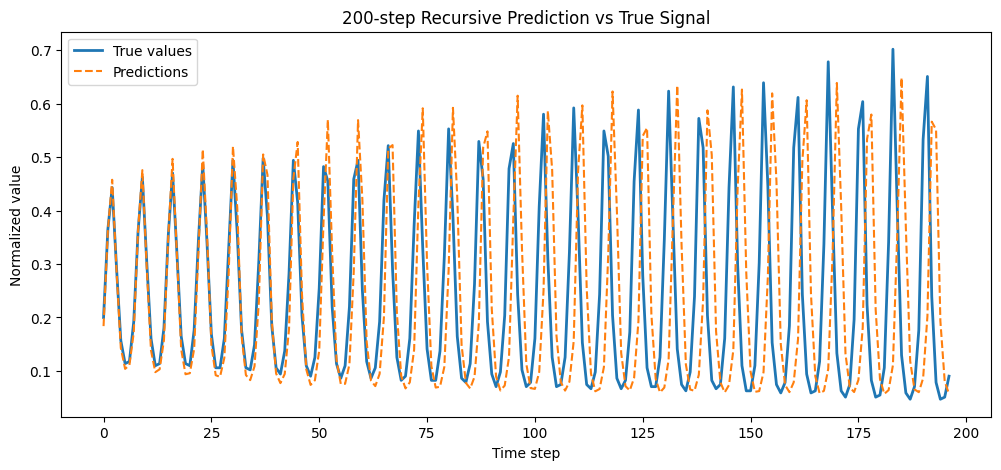

In [22]:
# hyperparameters
window_size = 16
hidden_size = 64
num_layers = 2
epochs = 500
learning_rate = 5e-4
#---------------------------------------------------

# create data
series_full = pd.Series(data['Xtrain'].flatten())
series_full = data_cleaning(series_full).values

# recreate dataset with current chosen window
df = pd.Series(data['Xtrain'].flatten())
df = data_cleaning(df)

X, Y = zip(*slices(df, window_size))

X = np.array(X).reshape(-1, window_size, 1)
Y = np.array(Y).reshape(-1, 1)

split = int(0.8 * len(X))

X_train, X_val = X[:split], X[split:]
Y_train, Y_val = Y[:split], Y[split:]

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
Y_val = torch.tensor(Y_val, dtype=torch.float32)

# create model
model = LSTMModel(hidden_size=hidden_size, num_layers=num_layers)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5, # halve learning rate when plateauing
    patience=10, # wait 10 epochs
    min_lr=1e-5
)

#Shuffle training data
dataset = TensorDataset(X_train, Y_train)
loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

#-------------------------------------------------
# training
#-------------------------------------------------
for epoch in range(epochs):
    model.train()

    train_loss_epoch = 0.0

    for X_batch, Y_batch in loader:
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, Y_batch)
        loss.backward() # backpropagation
        optimizer.step() # update parameters

        train_loss_epoch += loss.item()

    train_loss_epoch /= len(loader)
    #print(train_loss_epoch)

    # evaluation for schedular / for automatic learning rate decay at plateau
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, Y_val).item()
    
    scheduler.step(val_loss)
#-------------------------------------------------

#-------------------------------------------------
# 200-step evaluation
#-------------------------------------------------
start_idx = split
start_window = series_full[start_idx:start_idx+window_size]

# determine max possible steps
max_steps = len(series_full) - (start_idx + window_size)
steps = min(200, max_steps)

true_future = series_full[start_idx+window_size:start_idx+window_size+steps] # true values

# convert start window to tensor
start_tensor = torch.tensor(start_window.reshape(window_size, 1), dtype=torch.float32)

preds = recursive_predict(model, start_tensor, steps) # predictions

mae_200 = mean_absolute_error(true_future, preds)
mse_200 = mean_squared_error(true_future, preds)

print(f"\n{steps}-step MAE: {mae_200:.4f}")
print(f"\n{steps}-step MSE: {mse_200:.4f}")

#-----------------------
# plot
#-----------------------
import matplotlib.pyplot as plt

# Create x-axis (time steps)
t = range(len(true_future))

plt.figure(figsize=(12, 5))

# True signal
plt.plot(t, true_future, label="True values", linewidth=2)

# Predicted signal
plt.plot(t, preds, label="Predictions", linestyle='--')

plt.title("200-step Recursive Prediction vs True Signal")
plt.xlabel("Time step")
plt.ylabel("Normalized value")
plt.legend()

plt.show()
